# Phase Diagram Mapping with the Accelerated Backends

`binplot` and `ternplot` accept `method='grid'`: instead of tracing zero-phase
fraction boundaries (the default `method='zpf'` strategy), the grid method
computes a dense equilibrium grid and reads the phase boundaries off the
tie-line endpoints, which are equilibrium outputs and therefore accurate to
solver precision. Dense grids are exactly what the accelerated backends are
good at, so this turns phase diagram mapping into an interactive operation.

Both methods below compute the full Al-Ni binary — eight phases including the
ordered gamma-prime region.

In [1]:
import time
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pycalphad
from pycalphad import Database, Workspace, calculate, equilibrium, variables as v

# The backend to demonstrate: 'c++' runs generated kernels on the CPU,
# 'gpu' runs the same kernels through CuPy on an NVIDIA or AMD GPU.
BACKEND = 'c++'

def timed(label, fn):
    """Run fn(), print and return (result, elapsed seconds)."""
    start = time.perf_counter()
    result = fn()
    elapsed = time.perf_counter() - start
    print(f'{label}: {elapsed:.1f} s')
    return result, elapsed


In [2]:
from pycalphad import binplot
dbf = Database('../databases/NI_AL_DUPIN_2001.TDB')
comps = ['AL', 'NI', 'VA']
phases = sorted(dbf.phases.keys())
conditions = {v.N: 1, v.P: 101325, v.T: (300, 2000, 10), v.X('AL'): (0, 1, 0.02)}

# Warm the kernel cache.
with pycalphad.backend(BACKEND):
    equilibrium(dbf, comps, phases, {v.N: 1, v.P: 101325, v.T: 800, v.X('AL'): 0.3});

## Reference ZPF mapping

binplot (reference, ZPF mapping): 35.6 s


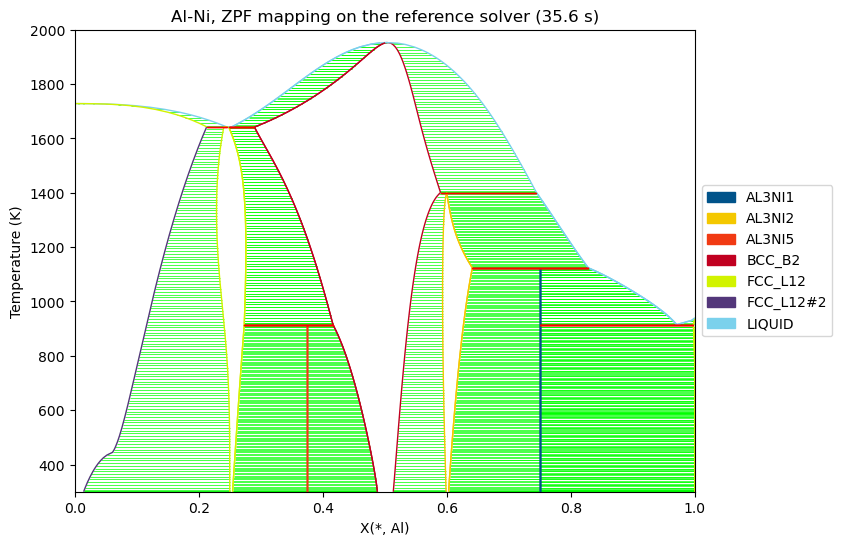

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
_, t_zpf = timed('binplot (reference, ZPF mapping)', lambda: binplot(
    dbf, comps, phases, conditions, plot_kwargs={'ax': ax}))
ax.set_title(f'Al-Ni, ZPF mapping on the reference solver ({t_zpf:.1f} s)');

## Grid mapping on the accelerated backend

binplot (accelerated, grid method): 2.5 s
speedup: 14.5x


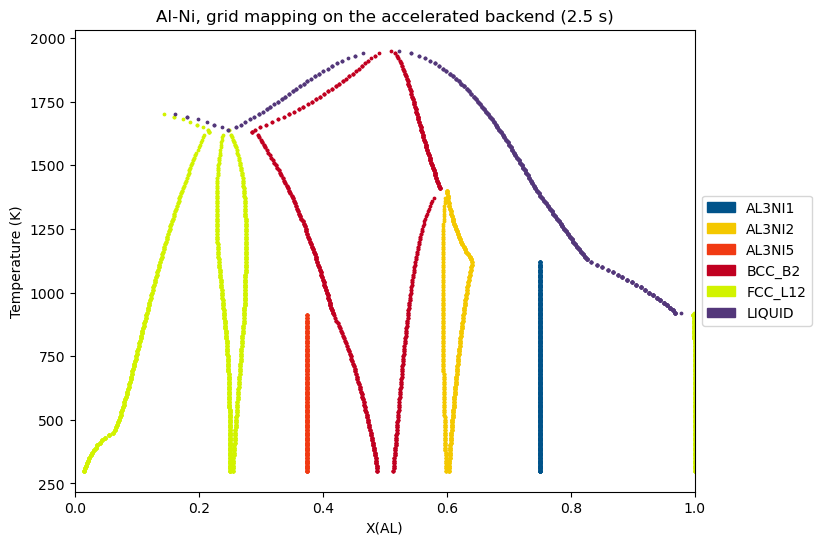

In [4]:
pycalphad.set_backend(BACKEND)
fig, ax = plt.subplots(figsize=(8, 6))
_, t_grid = timed('binplot (accelerated, grid method)', lambda: binplot(
    dbf, comps, phases, conditions, method='grid', plot_kwargs={'ax': ax}))
pycalphad.set_backend('default')
ax.set_title(f'Al-Ni, grid mapping on the accelerated backend ({t_grid:.1f} s)')
print(f'speedup: {t_zpf / t_grid:.1f}x')

Boundary points from the grid method are tie-line endpoints of converged
equilibria, so they agree with the reference ZPF boundaries to solver accuracy
(the visual difference between the two figures is point density and rendering,
not thermodynamics).

The same works for isothermal ternary sections:

ternplot (accelerated, grid method): 5.7 s


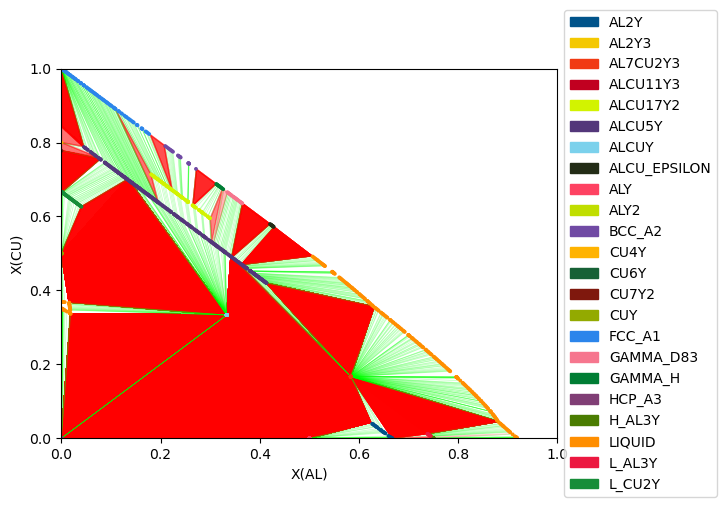

In [5]:
from pycalphad import ternplot
tdb_aucuy = Database('../databases/Al-Cu-Y.tdb')
tern_conds = {v.N: 1, v.P: 101325, v.T: 1100,
              v.X('AL'): (0, 1, 0.015), v.X('CU'): (0, 1, 0.015)}
pycalphad.set_backend(BACKEND)
_, t_tern = timed('ternplot (accelerated, grid method)', lambda: ternplot(
    tdb_aucuy, ['AL', 'CU', 'Y', 'VA'], sorted(tdb_aucuy.phases.keys()), tern_conds,
    x=v.X('AL'), y=v.X('CU'), method='grid'))
pycalphad.set_backend('default')